In [ ]:
pip install kaggle

In [ ]:
# Define the dataset slug (from the Kaggle URL)
dataset_slug = 'handekln/movielens-20m-dataset'

# Define the destination directory
destination_dir = 'DATA'

# Create the destination directory if it doesn't exist
import os
if not os.path.exists(destination_dir):
    os.makedirs(destination_dir)

# Download and unzip the dataset using Kaggle CLI
# The -p flag specifies the path where to download the dataset
# The --unzip flag extracts the content of the zip file after downloading
!kaggle datasets download -d {dataset_slug} -p {destination_dir} --unzip

print(f"Dataset downloaded and unzipped to '{destination_dir}/'")

Dataset URL: https://www.kaggle.com/datasets/handekln/movielens-20m-dataset
License(s): unknown
100% 195M/195M [00:00<00:00, 225MB/s]

Dataset downloaded and unzipped to 'DATA/'


ratings.csv userId | movieId | rating | timestamp

movies.csv movieId | title | genres

tags.csv userId | movieId | tag | timestamp

links.csv movieId | imdbId | tmdbId

genome_scores.csv movieId | tagId | relevance

genome_tags.csv tagId | tag



User → rates movie → ratings.csv

Movie → has info → movies.csv

Movie → has meaning → tags / genome

Movie → links external → links.csv

In [ ]:
import pandas as pd

movies = pd.read_csv('/content/DATA/archive/movie.csv')
ratings = pd.read_csv('/content/DATA/archive/rating.csv')



In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [ ]:
movies.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB


In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 610.4+ MB


In [ ]:
movies['genres'].value_counts()

,count
genres,
Drama,4520
Comedy,2294
Documentary,1942
Comedy|Drama,1264
Drama|Romance,1075
...,...
Action|Comedy|Crime|Western,1
Action|Fantasy|Sci-Fi|Thriller,1
Action|Drama|Fantasy|Horror|Mystery|Sci-Fi|Thriller,1


In [ ]:
print("=== RATINGS ===")
print(f"Total ratings:    {len(ratings):,}")
print(f"Unique users:     {ratings['userId'].nunique():,}")
print(f"Unique movies:    {ratings['movieId'].nunique():,}")
print(f"Rating scale:     {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"Average rating:   {ratings['rating'].mean():.2f}")

=== RATINGS ===
Total ratings:    20,000,263
Unique users:     138,493
Unique movies:    26,744
Rating scale:     0.5 – 5.0
Average rating:   3.53


In [ ]:


# How many movies has the average user rated?
ratings_per_user = ratings.groupby('userId')['movieId'].count()
print(f"\nRatings per user:")
print(f"  min:    {ratings_per_user.min()}")
print(f"  median: {ratings_per_user.median():.0f}")
print(f"  max:    {ratings_per_user.max()}")

# How many ratings does the average movie have?
ratings_per_movie = ratings.groupby('movieId')['rating'].count()
print(f"\nRatings per movie:")
print(f"  min:    {ratings_per_movie.min()}")
print(f"  median: {ratings_per_movie.median():.0f}")
print(f"  max:    {ratings_per_movie.max()}")


Ratings per user:
  min:    20
  median: 68
  max:    9254

Ratings per movie:
  min:    1
  median: 18
  max:    67310


In [ ]:
(movies['genres'] =='').sum()


np.int64(0)

In [ ]:
(movies['genres'] =='no genres listed').sum()

np.int64(0)

In [ ]:
#Missing values
movies.isnull().sum()

,0
movieId,0
title,0
genres,0


In [ ]:
#Duplicates
movies.duplicated().sum()

np.int64(0)

<Axes: xlabel='rating'>

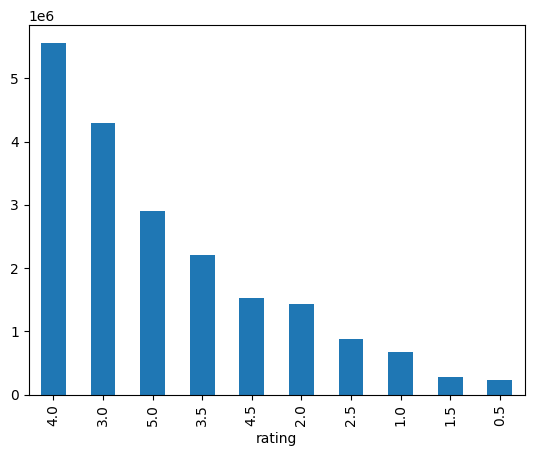

In [ ]:

#visualution
ratings['rating'].value_counts().plot(kind='bar')
#

In [ ]:
movies['genres'] = movies['genres'].fillna('')


In [ ]:

movies = movies.drop_duplicates()

In [ ]:
l = set()
# Iterate over each row's genres, split them, and add to the set
for genre_list in movies['genres'].str.split('|'):
    for genre in genre_list:
        if genre and genre != '(no genres listed)': # Ensure valid genre and not the placeholder
            l.add(genre)
print(l)

{'Fantasy', 'Crime', 'Mystery', 'Adventure', 'Thriller', 'Western', 'Film-Noir', 'IMAX', 'Comedy', 'Musical', 'Horror', 'War', 'Children', 'Animation', 'Drama', 'Sci-Fi', 'Documentary', 'Romance', 'Action'}


In [ ]:
print (len(l))

19


In [ ]:
#vectoration
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres'])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [ ]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

In [ ]:
def Recommendations(movie_title, top_k=5):
    matches = movies[movies['title'].str.contains(movie_title, case=False, na=False,regex=False)]

    if matches.empty:
        return "Movie not found."

    exact_title = matches.iloc[0]['title']
    idx = indices[exact_title]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_k+1]

    movie_indices = [i[0] for i in sim_scores]
    return movies['title'].iloc[movie_indices]

In [ ]:
print("\n── Recommendations for Star Wars (1977) ──")
print( Recommendations('Star Wars (1977)', 5))




── Recommendations for Star Wars (1977) ──
Movie not found.


In [ ]:
print(Recommendations("Star Wars", 5))

257             Star Wars: Episode IV - A New Hope (1977)
313                                       Stargate (1994)
438                                 Demolition Man (1993)
1171    Star Wars: Episode V - The Empire Strikes Back...
1184    Star Wars: Episode VI - Return of the Jedi (1983)
Name: title, dtype: object


In [ ]:
Recommendations('Fargo', 5)

,title
602,Fargo (1996)
1015,Freeway (1996)
3179,Man Bites Dog (C'est arrivé près de chez vous)...
4148,Beautiful Creatures (2000)
5904,Confessions of a Dangerous Mind (2002)


In [ ]:
'''import joblib
joblib.dump((movies, cosine_sim, indices), "movie_recommender.joblib")
joblib.dump(movies, "movies.pkl")
joblib.dump(cosine_sim, "similarity.pkl")
joblib.dump(indices, "indices.pkl")'''


'''
joblib.dump(tfidf, "tfidf.pkl")
joblib.dump(tfidf_matrix, "tfidf_matrix.pkl")
'''


'\njoblib.dump(tfidf, "tfidf.pkl")\njoblib.dump(tfidf_matrix, "tfidf_matrix.pkl")\n'

In [ ]:
import pandas as pd

# ── LOAD DATA ─────────────────────────────────────────────────────────────────


# ── PREPROCESS ────────────────────────────────────────────────────────────────

movies['genres_list'] = movies['genres'].apply(lambda g: g.split('|'))

# aggregate ratings per movie
agg = ratings.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

# merge into movies dataframe
movies = movies.merge(agg, on='movieId', how='left')


In [ ]:


# ── EXTRACT YEAR ──────────────────────────────────────────────────────────────

movies['year'] = (
    movies['title']
    .str.extract(r'\((\d{4})\)')   # grab 4 digits inside parentheses
    .astype(float)                  # float not int — handles missing values (NaN)
)

# peek at results
movies[['title', 'year']].head()
# "Toy Story (1995)"  → 1995.0
# "GoodFellas (1990)" → 1990.0

,title,year
0,Toy Story (1995),1995.0
1,Jumanji (1995),1995.0
2,Grumpier Old Men (1995),1995.0
3,Waiting to Exhale (1995),1995.0
4,Father of the Bride Part II (1995),1995.0


In [ ]:
# ── DECADE HELPER ─────────────────────────────────────────────────────────────

def year_to_decade(year):
    """ 1995 → '1990s',  2003 → '2000s' """
    return f"{int(year) // 10 * 10}s"

movies['decade'] = movies['year'].dropna().apply(year_to_decade)

In [ ]:
movies.head()

,movieId,title,genres,genres_list,avg_rating,num_ratings,year,decade
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",3.921240,49695.0,1995.0,1990s
1,2,Jumanji (1995),Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]",3.211977,22243.0,1995.0,1990s
2,3,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]",3.151040,12735.0,1995.0,1990s
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[Comedy, Drama, Romance]",2.861393,2756.0,1995.0,1990s
4,5,Father of the Bride Part II (1995),Comedy,[Comedy],3.064592,12161.0,1995.0,1990s


In [ ]:
import re


# ── FILTER BY DECADE ──────────────────────────────────────────────────────────

DECADES = ['1970s', '1980s', '1990s', '2000s', '2010s']

def top_by_genre_and_decade(selected_genres, selected_decade=None,
                             top_n=5, min_ratings=50):
    """
    selected_genres  : list — e.g. ['Action', 'Thriller']
    selected_decade  : str  — e.g. '1990s', or None to skip filter
    """
    mask = movies['genres_list'].apply(
        lambda g: all(genre in g for genre in selected_genres)
    ) & (movies['num_ratings'] >= min_ratings)

    # apply decade filter only if one was selected
    if selected_decade:
        mask &= (movies['decade'] == selected_decade)

    filtered = movies[mask].copy()

    if filtered.empty:
        return f"No results for {selected_genres} in {selected_decade or 'any decade'}."

    top = (filtered
           .sort_values('avg_rating', ascending=False)
           .head(top_n)[['title', 'year', 'genres', 'avg_rating', 'num_ratings']])

    top['avg_rating'] = top['avg_rating'].round(2)
    top['year'] = top['year'].astype(int)

    return top.reset_index(drop=True)

In [ ]:
top_by_genre_and_decade(['Drama'], selected_decade='1990s')


,title,year,genres,avg_rating,num_ratings
0,"Shawshank Redemption, The (1994)",1994,Crime|Drama,4.45,63366.0
1,Schindler's List (1993),1993,Drama|War,4.31,50054.0
2,Fight Club (1999),1999,Action|Crime|Drama|Thriller,4.23,40106.0
3,Goodfellas (1990),1990,Crime|Drama,4.18,26406.0
4,Life Is Beautiful (La Vita è bella) (1997),1997,Comedy|Drama|Romance|War,4.18,18156.0


In [ ]:
top_by_genre_and_decade(['Action', 'Sci-Fi'], selected_decade='1980s')


,title,year,genres,avg_rating,num_ratings
0,Star Wars: Episode V - The Empire Strikes Back...,1980,Action|Adventure|Sci-Fi,4.19,45313.0
1,Blade Runner (1982),1982,Action|Sci-Fi|Thriller,4.13,30526.0
2,Laputa: Castle in the Sky (Tenkû no shiro Rapy...,1986,Action|Adventure|Animation|Children|Fantasy|Sc...,4.06,3537.0
3,Aliens (1986),1986,Action|Adventure|Horror|Sci-Fi,4.01,27206.0
4,Star Wars: Episode VI - Return of the Jedi (1983),1983,Action|Adventure|Sci-Fi,4.00,46839.0


In [ ]:
top_by_genre_and_decade(['Comedy'], selected_decade=None)  # no decade filter

,title,year,genres,avg_rating,num_ratings
0,Dr. Strangelove or: How I Learned to Stop Worr...,1964,Comedy|War,4.25,23220.0
1,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",2001,Comedy|Romance,4.20,24349.0
2,"Thin Man, The (1934)",1934,Comedy|Crime,4.18,3358.0
3,Wallace & Gromit: The Wrong Trousers (1993),1993,Animation|Children|Comedy|Crime,4.18,15022.0
4,"Princess Bride, The (1987)",1987,Action|Adventure|Comedy|Fantasy|Romance,4.18,32586.0


In [ ]:
def top_by_genre_and_years(selected_genres, year_from=None, year_to=None,
                            top_n=5, min_ratings=50):
    mask = movies['genres_list'].apply(
        lambda g: all(genre in g for genre in selected_genres)
    ) & (movies['num_ratings'] >= min_ratings)

    if year_from:
        mask &= (movies['year'] >= year_from)
    if year_to:
        mask &= (movies['year'] <= year_to)

    filtered = movies[mask].copy()

    if filtered.empty:
        return "No results found."

    return (filtered
            .sort_values('avg_rating', ascending=False)
            .head(top_n)[['title', 'year', 'avg_rating', 'num_ratings']]
            .reset_index(drop=True))



In [ ]:
# examples
top_by_genre_and_years(['Thriller'], year_from=1990, year_to=1999)


,title,year,avg_rating,num_ratings
0,"Usual Suspects, The (1995)",1995.0,4.334372,47006.0
1,Fight Club (1999),1999.0,4.227123,40106.0
2,"Matrix, The (1999)",1999.0,4.187186,51334.0
3,"Silence of the Lambs, The (1991)",1991.0,4.177057,63299.0
4,Pulp Fiction (1994),1994.0,4.174231,67310.0


In [ ]:
top_by_genre_and_years(['Animation'], year_from=2010)

,title,year,avg_rating,num_ratings
0,Toy Story 3 (2010),2010.0,4.012974,5781.0
1,How to Train Your Dragon (2010),2010.0,4.000420,4761.0
2,"Batman: The Dark Knight Returns, Part 2 (2013)",2013.0,3.882038,373.0
3,Paperman (2012),2012.0,3.878049,205.0
4,La Luna (2011),2011.0,3.877778,90.0


In [ ]:
top_by_genre_and_years(['Comedy', 'Romance'])


,title,year,avg_rating,num_ratings
0,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",2001.0,4.197072,24349.0
1,"Princess Bride, The (1987)",1987.0,4.176732,32586.0
2,Life Is Beautiful (La Vita è bella) (1997),1997.0,4.175837,18156.0
3,City Lights (1931),1931.0,4.174123,2593.0
4,"Philadelphia Story, The (1940)",1940.0,4.171426,6583.0


In [ ]:
top_by_genre_and_years(['Thriller', 'Crime'], min_ratings=200)

,title,year,avg_rating,num_ratings
0,"Usual Suspects, The (1995)",1995.0,4.334372,47006.0
1,City of God (Cidade de Deus) (2002),2002.0,4.235410,12937.0
2,Fight Club (1999),1999.0,4.227123,40106.0
3,Chinatown (1974),1974.0,4.199673,15310.0
4,M (1931),1931.0,4.193171,4232.0


In [ ]:
top_by_genre_and_years(['Action'])


,title,year,avg_rating,num_ratings
0,Seven Samurai (Shichinin no samurai) (1954),1954.0,4.274180,11611.0
1,Band of Brothers (2001),2001.0,4.263182,4305.0
2,City of God (Cidade de Deus) (2002),2002.0,4.235410,12937.0
3,North by Northwest (1959),1959.0,4.233538,15627.0
4,Fight Club (1999),1999.0,4.227123,40106.0


In [ ]:
C = ratings['rating'].mean()
m = 100

movies['weighted_score'] = (
    (movies['num_ratings'] / (movies['num_ratings'] + m)) * movies['avg_rating']
    +
    (m / (movies['num_ratings'] + m)) * C
)